# Imports & Functions

In [37]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import numpy as np
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.tree import _tree
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
def extract_readable_rules(tree_model, feature_names, class_names, min_samples=20):
    """
    Walks all root-to-leaf paths and formats them as plain-language clinical rules.
    Filters out leaves with too few patients.
    """
    tree_ = tree_model.tree_

    rules = []

    def recurse(node, path):

        if tree_.children_left[node] == _tree.TREE_LEAF:  # Leaf node
            samples = tree_.n_node_samples[node]
            if samples < min_samples:
                return

            values = tree_.value[node][0]
            total = sum(values)
            class_idx = np.argmax(values)
            confidence = values[class_idx] / total * 100
            label = class_names[class_idx]

            if path:
                rule_str = "IF " + "\n   AND ".join(path)
                rule_str += f"\n→ THEN delivery is likely: {'CESAREAN' if label==1 else 'NATURAL'}"
                rule_str += f"\n   (Confidence: {confidence:.1f}%,  Patients matching: {int(samples)})\n"
                rules.append((confidence, samples, rule_str))
        else:
            # Look up feature name inline, only for non-leaf nodes
            feat_idx = tree_.feature[node]
            feat = feature_names[feat_idx]   # safe — only called on split nodes
            threshold = tree_.threshold[node]
            left_child  = tree_.children_left[node]
            right_child = tree_.children_right[node]
            recurse(left_child,  path + [f"{feat} ≤ {threshold:.2f}"])
            recurse(right_child, path + [f"{feat} > {threshold:.2f}"])

    recurse(0, [])

    # Sort by confidence descending
    rules.sort(key=lambda x: x[0], reverse=True)
    return [r[2] for r in rules]


In [38]:
def evaluate_model(y_test, y_pred, y_prob, plot_conf_matx=False):
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    print("Accuracy:", round(accuracy,4))
    print("Precision:", round(precision,4))
    print("Recall:", round(recall,4))
    print("F1-score:", round(f1,4))
    print("ROC-AUC:", round(auc,4))

    if plot_conf_matx:
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title("Confusion Matrix")
        plt.show()

# Load Data

In [15]:
df = pd.read_csv("final_cleaned_data.csv")

print(df.shape)
df.head()

(1650, 72)


,index,id,moth_age,moth_weight,moth_height,parent_relat,race,num_preg,num_births,num_stillborns,...,kidney_eval,fetal_bladder_eval,placenta_vessels_eval,fetal_limbs_eval,nb_attachment_eval,spinal_processes_eval,preeclampsia,no_diabetes,prev_diabetes,pregnancy_diabetes
0,1,213997.0,36.0,72.0,160.0,1.0,0.0,6.0,4.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,2,1279574.0,39.0,72.0,159.5,0.0,0.0,4.0,4.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,3,2319555.0,21.0,72.0,159.5,0.0,1.0,2.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,4,2518474.0,29.0,66.0,161.0,1.0,0.0,2.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,5,2528353.0,26.0,69.0,150.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [16]:
# drop "index" and "id"
df = df.drop(columns=["index", "id"])
df.head()

,moth_age,moth_weight,moth_height,parent_relat,race,num_preg,num_births,num_stillborns,num_maternal_deaths,cnt_abortions,...,kidney_eval,fetal_bladder_eval,placenta_vessels_eval,fetal_limbs_eval,nb_attachment_eval,spinal_processes_eval,preeclampsia,no_diabetes,prev_diabetes,pregnancy_diabetes
0,36.0,72.0,160.0,1.0,0.0,6.0,4.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,39.0,72.0,159.5,0.0,0.0,4.0,4.0,4.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,21.0,72.0,159.5,0.0,1.0,2.0,2.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,29.0,66.0,161.0,1.0,0.0,2.0,2.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,26.0,69.0,150.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [17]:
# Change type for categoricals
binary_cols = [col for col in df.columns if (df[col].nunique() == 2 or df[col].nunique() == 1)]

df[binary_cols] = df[binary_cols].astype('category')

print(f"Changed {len(binary_cols)} columns to category type.")
print("\nData types after conversion:")
print(df.dtypes)

Changed 38 columns to category type.

Data types after conversion:
moth_age                  float64
moth_weight               float64
moth_height               float64
parent_relat             category
race                     category
                           ...   
spinal_processes_eval    category
preeclampsia             category
no_diabetes              category
prev_diabetes            category
pregnancy_diabetes       category
Length: 70, dtype: object


In [5]:
# According to future analysis (remove redundant feature)
df = df.drop(columns=['no_diabetes'])
df.shape

(1650, 69)

# Multicollinearity Analysis
To Find Highly Correlated Features

In this section, we investigate correlations between features to identify potential redundancy within the dataset.

Highly correlated features often contain overlapping information, which can increase model complexity without improving predictive performance.

To perform this analysis appropriately, feature types must be considered separately:

* **Numerical features** are compared with other numerical features using correlation measures suitable for continuous variables.
* **Categorical features** are compared with other categorical features using association measures designed for discrete variables.

By identifying strongly associated feature pairs, we can detect redundant variables and better understand the structure of the dataset.

## Numerical vs Numerical


In [18]:
num_df = df.select_dtypes(include=['int64', 'float64'])

### Pearson Correlation
Linear relation between pairs of numerical features

In [19]:
corr_matrix = num_df.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper.stack()
         .reset_index()
)

# show results
high_corr_pairs.columns = [
    'feature_1',
    'feature_2',
    'correlation'
]

high_corr_pairs = (
    high_corr_pairs[
        high_corr_pairs['correlation'] > 0.7
    ]
    .sort_values('correlation', ascending=False)
)

high_corr_pairs.head(20)

,feature_1,feature_2,correlation
100,num_preg,num_births,0.868492


Women with more pregnancies tend to have more births, approximately in a linear fashion.
A Pearson correlation of 0.87 is quite high.
This relationship is expected biologically.
But these are different clinical concepts. So, keep both.

### Spearman Correlation
If relationships may be monotonic but not linear

In [20]:
corr_matrix = num_df.corr(method='spearman')

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper.stack()
         .reset_index()
)

# show results
high_corr_pairs.columns = [
    'feature_1',
    'feature_2',
    'correlation'
]

high_corr_pairs = (
    high_corr_pairs[
        high_corr_pairs['correlation'] > 0.6
    ]
    .sort_values('correlation', ascending=False)
)

high_corr_pairs.head(20)

,feature_1,feature_2,correlation
100,num_preg,num_births,0.850018
661,fetal_head_circumference,fetal_abdominal_circumference,0.735138
630,temporal_bone_diameter,fetal_femur_length,0.725739
631,temporal_bone_diameter,fetal_weight_estimation,0.725101
628,temporal_bone_diameter,fetal_head_circumference,0.713982
662,fetal_head_circumference,fetal_femur_length,0.704193
727,fetal_femur_length,fetal_weight_estimation,0.700728
694,fetal_abdominal_circumference,fetal_femur_length,0.679417
695,fetal_abdominal_circumference,fetal_weight_estimation,0.648762
629,temporal_bone_diameter,fetal_abdominal_circumference,0.629181


The first rows, make perfect medical sense.They are all measuring fetal growth and fetal size.

A larger fetus tends to have:
* larger head circumference
* larger abdomen circumference
* longer femur
* larger estimated weight

The values are not high enough for automatic removal.

Analysis of Spearman values:
* < 0.7	Usually keep
* 0.7–0.9	Investigate
* \> 0.9	Strong candidate for removal
* \> 0.95	Often duplicate information

### Variance Inflation Factor (VIF)
Not for only pairwise relations

In [21]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

num_df = num_df.drop(["num_stillborns", "num_births", "num_maternal_deaths", "num_preg", "apgar", "cnt_abortions"], axis=1)

# Just for numeric columns
vif = pd.DataFrame({
    "feature": num_df.columns,
    "VIF": [
        variance_inflation_factor(num_df.values, i)
        for i in range(num_df.shape[1])
    ]
})

vif.sort_values("VIF", ascending=False)

,feature,VIF
2,moth_height,609.076088
22,brain_size_eval,443.314822
25,fetal_heart_rate_eval,340.893125
15,fetal_head_circumference,294.050834
16,fetal_abdominal_circumference,269.174388
14,temporal_bone_diameter,176.090379
19,cervical_length,130.366984
17,fetal_femur_length,122.630262
21,lateral_ventricles_size_anomaly_scan,120.455821
24,lips_nose_eval,103.014304


In [22]:
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = add_constant(num_df)

vif = pd.DataFrame({
    "feature": X.columns,
    "VIF": [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
})

vif.sort_values("VIF", ascending=False)

,feature,VIF
0,const,2313.444709
19,fetal_weight_estimation,2.134686
17,fetal_abdominal_circumference,2.031657
16,fetal_head_circumference,1.885662
15,temporal_bone_diameter,1.858809
18,fetal_femur_length,1.850422
23,brain_size_eval,1.532911
24,cisterna_magna_eval,1.156418
21,nuchal_skin_fold,1.103269
2,moth_weight,1.075190


VIF is not measuring pairwise correlation. It's measuring how well a feature can be predicted by all the other features combined.

(feature_i = β₀ + β₁X₁ + β₂X₂ + ...)

The results show that even though correlated features from Spearman are related, they are not redundant enough to create serious multicollinearity.

VIF Interpretation:
* 1	No multicollinearity
* 1–2	Very low
* 2–5	Mild
* 5–10	Moderate concern
* \>10	Serious concern

## Categorical vs Categorical

In [23]:
from itertools import combinations
from scipy.stats import chi2_contingency

def cramers_v(x, y):

    confusion = pd.crosstab(x, y)

    r, k = confusion.shape

    if min(r, k) <= 1:
        return np.nan

    chi2 = chi2_contingency(confusion)[0]

    n = confusion.sum().sum()

    return np.sqrt(
        chi2 / (n * (min(r, k) - 1))
    )


cat_cols = df.select_dtypes(
    include=['category', 'object']
).columns

results = []

for c1, c2 in combinations(cat_cols, 2):
    v = cramers_v(df[c1], df[c2])
    results.append((c1, c2, v))

cramer_pairs = (
    pd.DataFrame(results,columns=['feature_1', 'feature_2', 'cramers_v'])
    .sort_values(by='cramers_v', ascending=False)
)

In [24]:
cramer_pairs.head(10)

,feature_1,feature_2,cramers_v
700,no_diabetes,prev_diabetes,0.957254
429,choroid_plexus_cyst,choroid_plexus_anomaly_scan,0.516762
412,intra_cardiac_echo_focus,fetal_heart_chambers_eval,0.352157
462,pyelectasis,kidney_eval,0.268765
701,no_diabetes,pregnancy_diabetes,0.237881
350,glucose_tolerance_test,prev_diabetes,0.237436
349,glucose_tolerance_test,no_diabetes,0.231254
114,delivery_method,glucose_tolerance_test,0.210343
140,delivery_method,prev_diabetes,0.152430
139,delivery_method,no_diabetes,0.147046


Cramér's V	Meaning:
* < 0.2	Little association
* 0.2–0.4	Moderate
* 0.4–0.7	Strong
* \> 0.8	Very strong / potentially redundant


1. choroid_plexus_cyst and choroid_plexus_anomaly_scan has a moderately strong association. This makes clinical sense.
A cyst may often cause an abnormal scan result.

2. intra_cardiac_echo_focus and fetal_heart_chambers_eval has moderate association. Intracardiac echogenic focus tends to occur more often when heart chamber evaluation is abnormal.

3. pyelectasis and kidney_eval has weak-to-moderate association. Again, medically reasonable. Pyelectasis is a kidney-related finding.

But these relations are not strong enough to consider as redundancy.

In [25]:
pd.crosstab(
    df["no_diabetes"],
    df["prev_diabetes"]
)

prev_diabetes,0.0,1.0
no_diabetes,,
0.0,8,107
1.0,1535,0


The strongest value is for no_diabetes and prev_diabetes which are two columns of one-hot encoded column. Since, no_diabetes could find by zero values for prev_diabetes and preg_diabetes, it is **redundant** to keep this column.

Remove it!

In [26]:
df = df.drop(columns=['no_diabetes'])

In [27]:
df.shape

(1650, 69)

# Nonlinear Relationship of each column with label

Since the previous correlation analysis revealed no strong linear relationships between the features and the target variable, we next investigate potential non-linear dependencies.

For this purpose, we use the **`mutual_info_classif`** method to estimate the mutual information between each feature and the label.

Mutual information measures how much knowing the value of a feature reduces the uncertainty about the target variable. In other words, it quantifies how much information a feature provides for predicting the label. Unlike correlation coefficients, which measure only linear relationships, mutual information can capture both linear and non-linear associations.

A mutual information score of zero indicates that the feature and the target are independent, while higher values suggest that the feature contains more useful information for predicting the label.

The resulting scores allow us to identify features that may be important for classification, even when their linear correlation with the target is weak or absent.

In [28]:
X = df.drop("delivery_method", axis=1)
y = df["delivery_method"]

In [29]:
from sklearn.preprocessing import LabelEncoder

# must encode categorical columns (to convert them to numeric)
X_encoded = X.copy()

categorical_cols = X.select_dtypes(
    include=['object', 'category']
).columns

for col in categorical_cols:
    X_encoded[col] = LabelEncoder().fit_transform(
        X_encoded[col].astype(str)
    )

In [33]:
discrete_numeric_cols = [
    'num_preg',
    'num_births',
    'num_stillborns',
    'num_maternal_deaths',
    'count_abortions',
    'apgar'
]

discrete_cols = list(categorical_cols) + discrete_numeric_cols

discrete_mask = [
    col in categorical_cols
    for col in X_encoded.columns
]

In [34]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(
    X_encoded,
    y,
    discrete_features=discrete_mask,
    random_state=42
)

In [35]:
mi_df = pd.DataFrame({
    'feature': X_encoded.columns,
    'mutual_info': mi_scores
})

mi_df = mi_df.sort_values(
    'mutual_info',
    ascending=False
)

print(mi_df.head(10))

                                 feature  mutual_info
33               fetal_weight_estimation     0.168249
29                temporal_bone_diameter     0.084969
52                 fetal_heart_rate_eval     0.076842
49                        lips_nose_eval     0.075041
32                    fetal_femur_length     0.071673
14                  blood_nitrogen_level     0.058457
30              fetal_head_circumference     0.050517
31         fetal_abdominal_circumference     0.045737
43  lateral_ventricles_size_anomaly_scan     0.039702
35                      nuchal_skin_fold     0.037659


MI Score Interpretation:

* 0.00	    -> No relationship
* 0.01–0.05 ->	Weak
* 0.05–0.15 -> Moderate
* 0.15+	    -> Strong

So, fetal_weight_estimation has strong, Non-linear relation with the label. And other features like temporal_bone_diameter, fetal_heart_rate_eval, lips_nose_eval, and fetal_femur_lenght has moderate non-linear relation.

# Decision Tree Rules
Based on most important features extracted by RF

In [30]:
features = df.drop("delivery_method", axis=1)
labels = df["delivery_method"]

X_train, X_test, y_train, y_test = train_test_split(
    features, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

In [31]:
model = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# Extract Feature Importances
importances = model.feature_importances_
feature_names = features.columns

importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values(by="importance", ascending=False)
    .reset_index(drop=True)
)

In [32]:
importance_df.head(15)

,feature,importance
0,fetal_weight_estimation,0.134361
1,fetal_heart_rate_eval,0.084954
2,lips_nose_eval,0.062219
3,temporal_bone_diameter,0.059083
4,blood_nitrogen_level,0.044947
5,nuchal_skin_fold,0.038568
6,moth_age,0.037492
7,fetal_femur_length,0.037331
8,thyroid_stimulating_hormone,0.035996
9,fasting_blood_glucose,0.034118


Now, these are much more reasonable according to Non-linear relationship analysis.

In [33]:
# Use already-identified top features
k = 45
topk_features = importance_df.head(k)["feature"].tolist()

# Train a SHALLOW tree — depth 4-5 is ideal for medical readability (generate human-readable rules)
# A depth-30 tree - maximize predictive power
dt = DecisionTreeClassifier(
    max_depth=30,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=42
)
dt.fit(X_train[topk_features], y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",30
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",50
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [34]:
print("Depth:", dt.get_depth())
print("Leaves:", dt.get_n_leaves())

Depth: 8
Leaves: 21


In [35]:
# --- Export as plain text rules ---
rules_text = export_text(dt, feature_names=topk_features, show_weights=True)
print(rules_text)

|--- lips_nose_eval <= 5.72
|   |--- lips_nose_eval <= 5.64
|   |   |--- apgar <= 9.50
|   |   |   |--- cisterna_magna_eval <= 4.35
|   |   |   |   |--- weights: [15.30, 44.13] class: 1.0
|   |   |   |--- cisterna_magna_eval >  4.35
|   |   |   |   |--- weights: [26.52, 34.32] class: 1.0
|   |   |--- apgar >  9.50
|   |   |   |--- moth_age <= 29.50
|   |   |   |   |--- weights: [12.24, 52.96] class: 1.0
|   |   |   |--- moth_age >  29.50
|   |   |   |   |--- weights: [6.12, 56.88] class: 1.0
|   |--- lips_nose_eval >  5.64
|   |   |--- fetal_weight_estimation <= 268.50
|   |   |   |--- fetal_weight_estimation <= 265.50
|   |   |   |   |--- fetal_weight_estimation <= 222.50
|   |   |   |   |   |--- weights: [46.92, 18.63] class: 0.0
|   |   |   |   |--- fetal_weight_estimation >  222.50
|   |   |   |   |   |--- thyroid_stimulating_hormone <= 1.71
|   |   |   |   |   |   |--- weights: [25.50, 25.50] class: 0.0
|   |   |   |   |   |--- thyroid_stimulating_hormone >  1.71
|   |   |   |   |

In [40]:
readable_rules = extract_readable_rules(
    dt,
    feature_names=list(X_train[topk_features].columns),
    class_names=list(dt.classes_),   # e.g. ['cesarean', 'vaginal']
    min_samples=20
)

for rule in readable_rules:
    print(rule)
    print("-" * 50)

IF lips_nose_eval ≤ 5.72
   AND lips_nose_eval > 5.64
   AND fetal_weight_estimation ≤ 268.50
   AND fetal_weight_estimation > 265.50
   AND moth_height > 158.50
   AND moth_height ≤ 159.75
   AND fasting_blood_glucose > 77.50
   AND moth_age > 26.50
→ THEN delivery is likely: NATURAL
   (Confidence: 100.0%,  Patients matching: 100)

--------------------------------------------------
IF lips_nose_eval > 5.72
   AND fetal_heart_rate_eval > 144.50
   AND fasting_blood_glucose > 84.50
→ THEN delivery is likely: CESAREAN
   (Confidence: 98.2%,  Patients matching: 58)

--------------------------------------------------
IF lips_nose_eval ≤ 5.72
   AND lips_nose_eval > 5.64
   AND fetal_weight_estimation ≤ 268.50
   AND fetal_weight_estimation > 265.50
   AND moth_height > 158.50
   AND moth_height ≤ 159.75
   AND fasting_blood_glucose > 77.50
   AND moth_age ≤ 26.50
→ THEN delivery is likely: NATURAL
   (Confidence: 98.1%,  Patients matching: 102)

-------------------------------------------

# Final RF model with all important features
Important features from previous non-linear relationship and decision tree results and also the result of pairwise correlations with label.

In [65]:
features = df.drop("delivery_method", axis=1)
labels = df["delivery_method"]

In [66]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    features, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

In [75]:
most_imp_features = ["fetal_weight_estimation", "temporal_bone_diameter", "fetal_heart_rate_eval",
                     "lips_nose_eval", "fetal_femur_length", "fetal_femur_length", "blood_nitrogen_level",
                     "fetal_head_circumference", "fetal_abdominal_circumference", "nuchal_skin_fold",
                     "moth_age", "thyroid_stimulating_hormone", "fasting_blood_glucose", "cervical_length",
                     "apgar", "moth_weight", "brain_size_eval", "num_maternal_deaths", "pregnancy_related_plasma_protein_a", "moth_height", "thyroid_stimulating_hormone","num_births",
                     "num_preg", "num_births" , "nuchal_translucency_test", "cnt_abortions"]

len(most_imp_features)

26

Accuracy: 0.8212
Precision: 0.7608
Recall: 0.9464
F1-score: 0.8435
ROC-AUC: 0.8457


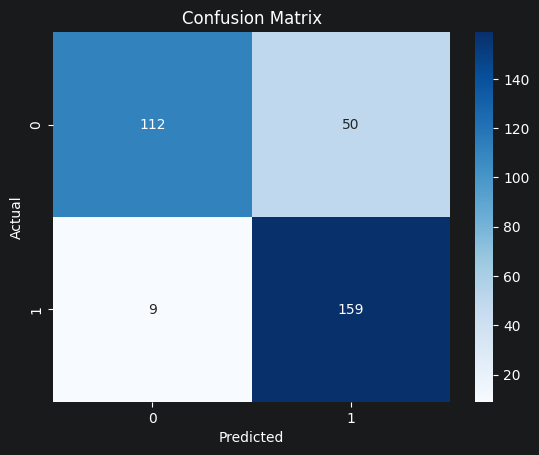

In [76]:
X = X_train[most_imp_features]
y = y_train

final_rf = RandomForestClassifier(
    n_estimators=1500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

final_rf.fit(X, y)

y_pred = final_rf.predict(X_test[most_imp_features])

# Probability of positive class (for AUC)
y_prob = final_rf.predict_proba(X_test[most_imp_features])[:,1]

evaluate_model(y_test, y_pred, y_prob, plot_conf_matx=True)

This result is comparable with the best RF that we had but here we just used 26 most important features calculated from 3 different analysis.